# A- Models clustering: models selections

In [13]:
import pandas as pd 
import os
import astrologics as ast
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import maboss
import re
import mpbn

In [39]:
# === PARAMETERS ===
models_folder = "models_selected/"
# or 
models_folder = "models_KI_cebpa/"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
base_dir = Path("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_test/infer/bn/submin")
final_dir = Path("/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_test")

In [14]:
# Create a folder with the models 
# Final folder
ensemble_dir = final_dir / "ensemble"
ensemble_dir.mkdir(exist_ok=True)

for folder in sorted(base_dir.iterdir()):
    if not folder.is_dir():
        continue
    model_file = folder / "model.bnet"
    if model_file.exists():
        destination = ensemble_dir / f"model_{folder.name}.bnet"
        shutil.copy2(model_file, destination)

print("Finished")

Finished


In [40]:
# Load the model path and create AstroLogics object
model = ast.ensemble(models_folder, project_name = 'bonesis')
model.create_simulation()

Simulation object created


Simulate all the models 

In [41]:
# Configure simulation parameters
model.simulation.update_parameters(max_time = 15, sample_count = 1000)
model.simulation.run_simulation()

Start simulation


  0%|          | 0/178 [00:00<?, ?it/s]

Simulation completed


Trajectory object created


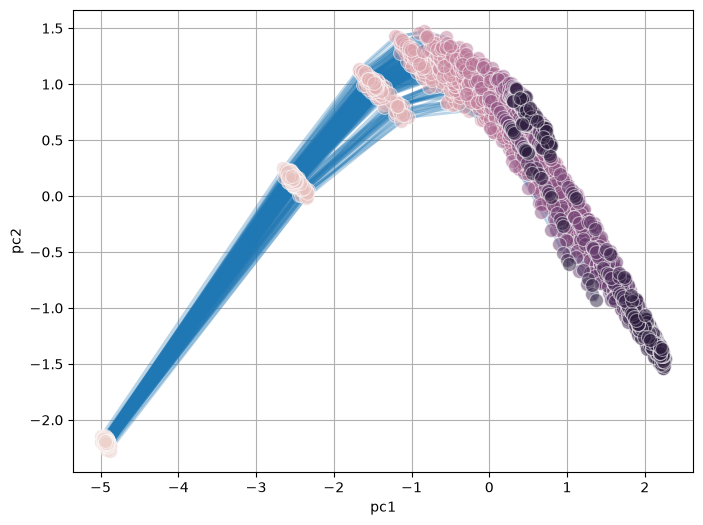

In [42]:
model.create_trajectory()
model.trajectory.pca_trajectory()
model.trajectory.plot_pca_trajectory(color = 'timepoint')

Distance matrix 

In [43]:
model.trajectory.calculate_distancematrix(mode = 'endpoint')

Calculating distance matrix for endpoint simulation...
Distance matrix calculated successfully.


Dimensionality Reduction and Visualization and clustering

/opt/conda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Calculated k-means clustering with 4 clusters.


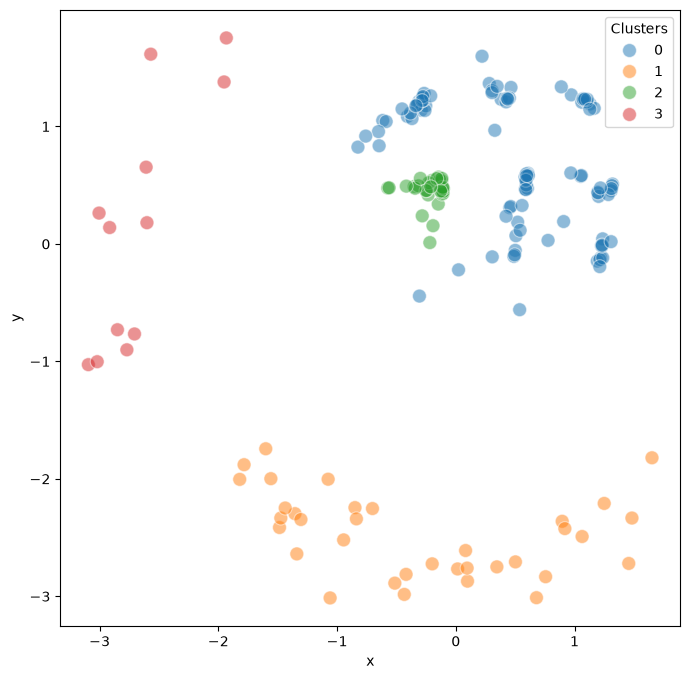

In [61]:
# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()

# Clustering
model.trajectory.calculate_kmean_cluster(n_cluster = 4,random_state = 0)
model.trajectory.plot_MDS(s = 100, fig_size = (8,8),plot_cluster = True)

Logic Function Analysis

In [59]:
model.create_logic()
model.logic.model_logic
model.logic.create_flattend_logic_clause()

model.logic.map_model_clusters(model.trajectory.cluster_dict)
model.logic.calculate_logic_statistic(pval_threshold = 0.0001)

Loading models logics


  0%|          | 0/178 [00:00<?, ?it/s]

Concatenate results into matrix


  0%|          | 0/178 [00:00<?, ?it/s]

Logic object created
Flatten models logic clauses


  0%|          | 0/178 [00:00<?, ?it/s]

Concatenate results into matrix


  0%|          | 0/178 [00:00<?, ?it/s]

Flattend logic clause created
Model clusters mapped to logic clauses


['chi2', 'p_value', 'Group', 'Node', 'Regulation']


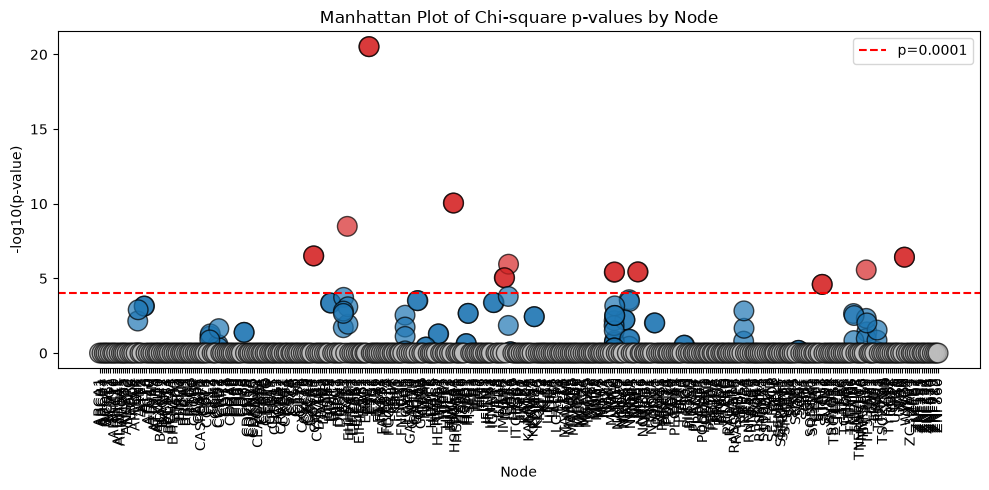

['chi2', 'p_value', 'Group', 'Node', 'Regulation', '-log10_p']


In [54]:
print(model.logic.stat_logic_df.columns.tolist())
model.logic.plot_manhattan()
print(model.logic.stat_logic_df.columns.tolist())

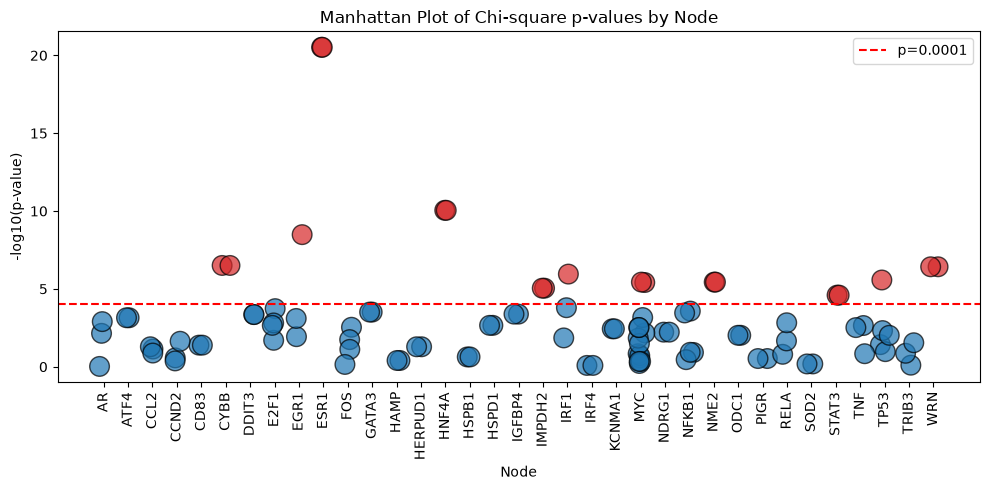

In [55]:
df_orig = model.logic.stat_logic_df

# Filter
model.logic.stat_logic_df = df_orig[df_orig['-log10_p'] != 0]
model.logic.plot_manhattan()
model.logic.stat_logic_df = df_orig

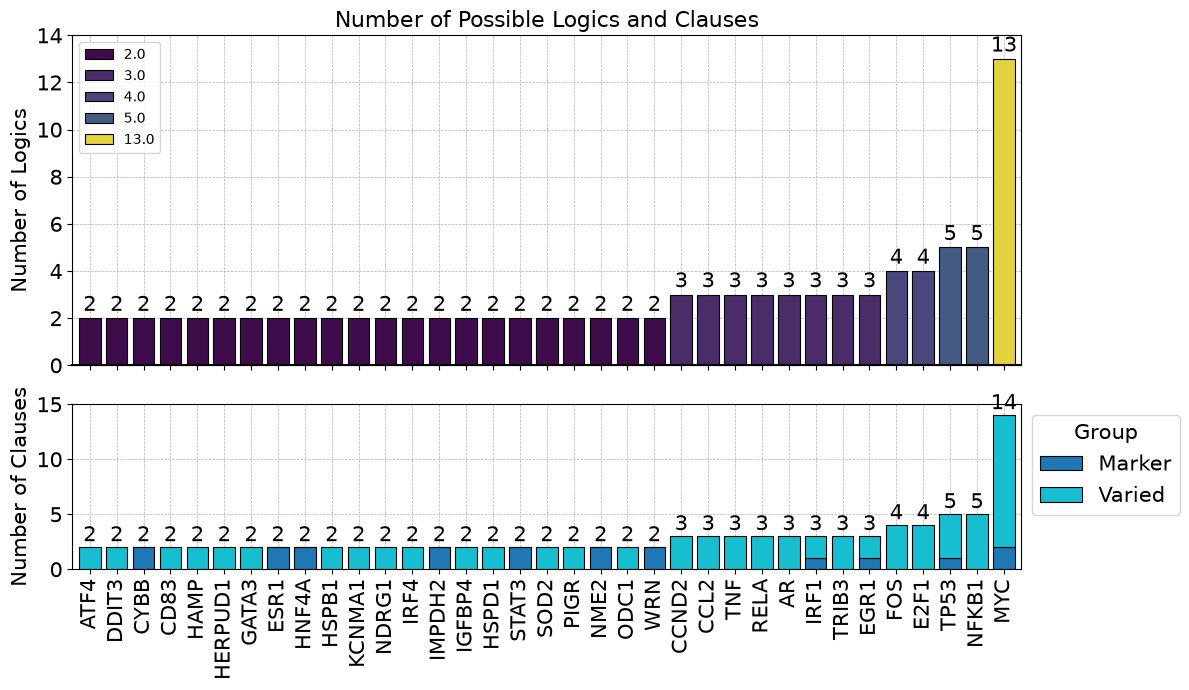

In [56]:
stat_orig = model.logic.stat_logic_df
enc_orig = model.logic.encoded_df

# Nodes to keep
nodes = stat_orig.loc[stat_orig["-log10_p"] != 0, "Node"].unique()

# Filter
model.logic.stat_logic_df = stat_orig[stat_orig["Node"].isin(nodes)]
model.logic.encoded_df = enc_orig[nodes]

model.logic.plot_logicstat_summary()

model.logic.stat_logic_df = stat_orig
model.logic.encoded_df = enc_orig

/opt/conda/lib/python3.12/site-packages/astrologics/trajectory_clustering.py:432: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  model_mtx = self.simulation_df.assign(type=self.simulation_df['model_id'].map(self.cluster_dict))


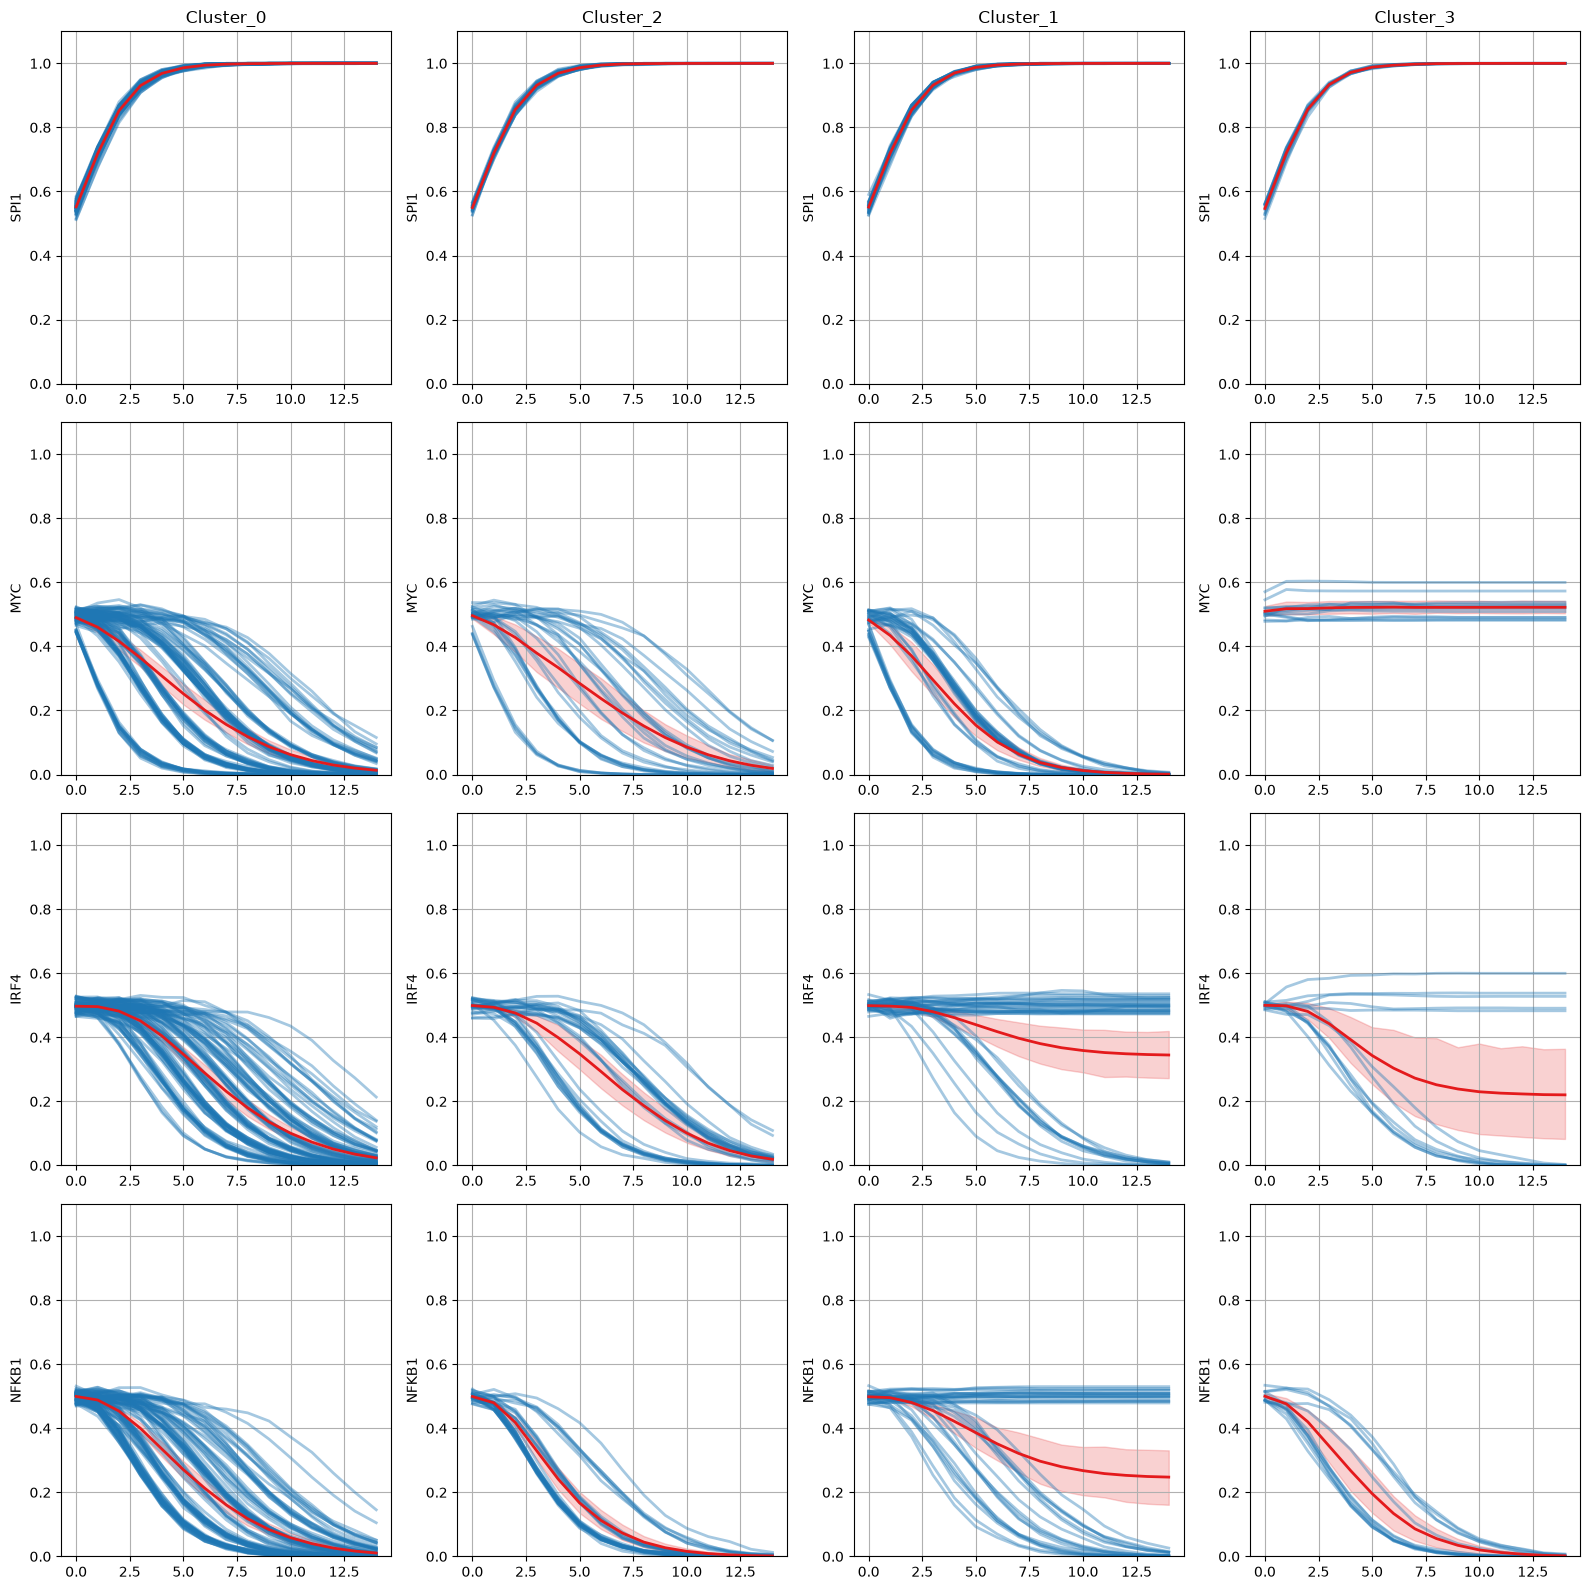

In [64]:
model.trajectory.plot_node_trajectory(node = ['SPI1','MYC','IRF4','NFKB1'])

<Figure size 1500x800 with 0 Axes>

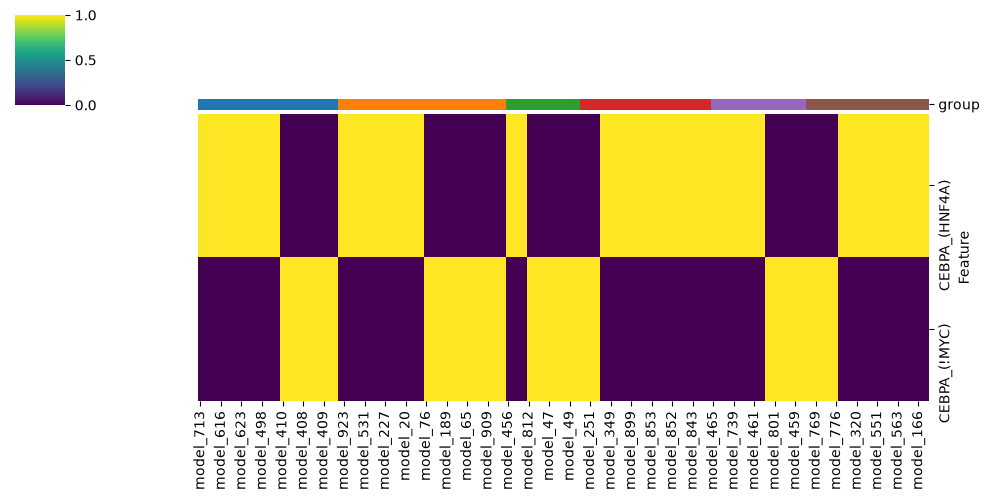

In [18]:
model.logic.plot_node_logic_heatmap(node = ['CEBPA'],fig_size = (15, 8))

<Figure size 800x800 with 0 Axes>

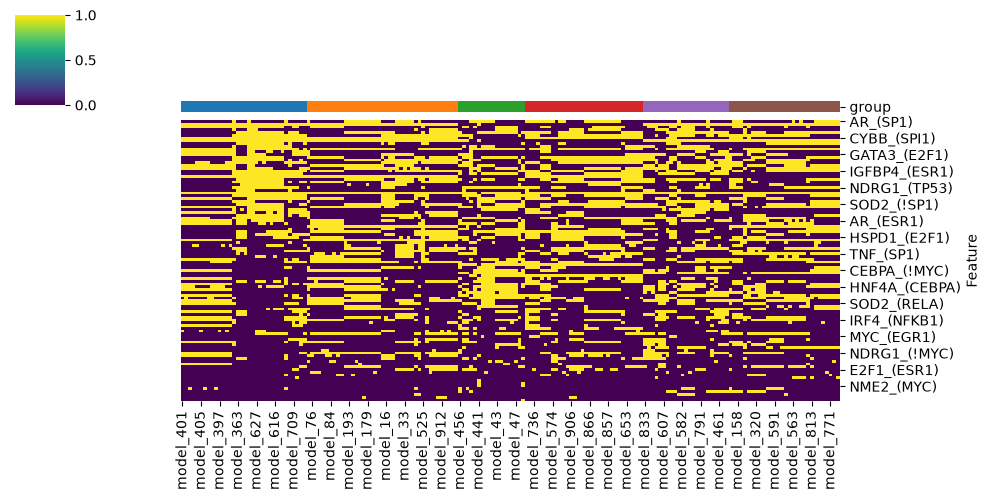

In [29]:
model.logic.plot_node_logic_heatmap(node = list(nodes),fig_size = (8, 8))

In [32]:
print(model.logic.stat_logic_df.shape)
print(model.logic.stat_logic_df.head())

print(model.logic.stat_logic_df["Group"].nunique())
print(model.trajectory.simulation_df["model_id"].nunique())

(468, 5)
                   chi2        p_value   Group   Node Regulation
Feature                                                         
AR_(ESR1)     70.492617   1.786432e-14  Marker     AR     (ESR1)
ATF4_(1)     846.309405  7.141212e-182  Marker   ATF4        (1)
CCL2_(FOS)    24.533250   6.243568e-05  Marker   CCL2      (FOS)
CCND2_(MYC)   74.706139   2.299155e-15  Marker  CCND2      (MYC)
CD83_(SP1)    37.899348   1.175430e-07  Marker   CD83      (SP1)
3
1000


In [36]:
models_folder=Path("models_selected")
rules = []

for model_file in models_folder.glob("*.bnet"):

    model_rules = {"model": model_file.stem}

    with open(model_file) as f:
        for line in f:

            line = line.strip()

            # Ignore les lignes vides et les commentaires
            if not line or line.startswith("#"):
                continue

            node, rule = line.split(",", 1)

            model_rules[node.strip()] = rule.strip()

    rules.append(model_rules)

rules_df = pd.DataFrame(rules).set_index("model")

rule_variability = (
    rules_df
    .nunique()
    .sort_values(ascending=False)
)

print(rule_variability.head(36))
print(len(rule_variability))
n_variable = (rule_variability > 1).sum()

print(f"Nb nodes variable : {n_variable}")

MYC        13
NFKB1       5
TP53        5
E2F1        4
FOS         4
CCND2       3
RELA        3
IRF1        3
TRIB3       3
CCL2        3
AR          3
EGR1        3
TNF         3
ODC1        2
WRN         2
PIGR        2
CEBPA       2
NDRG1       2
HNF4A       2
HSPD1       2
ESR1        2
HERPUD1     2
HSPB1       2
IGFBP4      2
GATA3       2
STAT3       2
IMPDH2      2
IRF4        2
CYBB        2
DDIT3       2
HAMP        2
NME2        2
ATF4        2
KCNMA1      2
SOD2        2
CD83        2
dtype: int64
397
Nb nodes variable : 36


In [37]:
nodes = ["CEBPA", "MYC", "FOS","HNF4A","IRF1","GATA3","NFKB1","STAT3","IRF4","ATF4","EGR1"]

for node in nodes:

    print(f"\n### {node}")

    if node in rules_df.columns:
        print(rules_df[node].value_counts(dropna=False))
    else:
        print("Node not found.")


### CEBPA
CEBPA
HNF4A    108
!MYC      70
Name: count, dtype: int64

### MYC
MYC
!FOS          39
!CEBPA        27
!TP53         21
ESR1          21
E2F1          15
SP1           12
!CEBPE        11
GATA3         10
NFKB1          8
EGR1           6
AR             6
!CTCF|NME2     1
E2F5|NME2      1
Name: count, dtype: int64

### FOS
FOS
STAT3    76
SPI1     54
TP53     40
ETS1      8
Name: count, dtype: int64

### HNF4A
HNF4A
RARA     95
CEBPA    83
Name: count, dtype: int64

### IRF1
IRF1
0        107
RELA      36
STAT3     35
Name: count, dtype: int64

### GATA3
GATA3
NFKB1    108
E2F1      70
Name: count, dtype: int64

### NFKB1
NFKB1
!FOS     84
RUNX1    43
GATA3    21
SP1      17
EGR1     13
Name: count, dtype: int64

### STAT3
STAT3
CEBPA    122
SPI1      56
Name: count, dtype: int64

### IRF4
IRF4
E2F1     94
NFKB1    84
Name: count, dtype: int64

### ATF4
ATF4
1      129
MYC     49
Name: count, dtype: int64

### EGR1
EGR1
1        84
SP1      54
!RELA    40
Name: count, dtyp

Subset models with KO or KI

In [38]:
models_folder=Path("models_selected")
output_folder = Path("models_KI_cebpa")
gene = "CEBPA"

for model_file in models_folder.glob("*.bnet"):

    new_lines = []

    with open(model_file, "r") as f:
        for line in f:
            if line.startswith(f"{gene},"):
                new_lines.append(f"{gene}, 1\n")
            else:
                new_lines.append(line)

    with open(output_folder / model_file.name, "w") as f:
        f.writelines(new_lines)

print("Done!")

print(f"{len(list(models_folder.glob('*.bnet')))} models saved in {output_folder}")

Done!
178 models saved in models_KI_cebpa


Subset models with rules CEBPA !MYC

In [66]:
input_folder = Path("models_selected")
output_folder = Path("models_subset_rules")
output_folder.mkdir(exist_ok=True)

for model_file in input_folder.glob("*.bnet"):

    with open(model_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()

        if line.startswith("CEBPA,"):
            rule = line.split(",")[1].strip()

            if rule == "!MYC":
                shutil.copy(model_file, output_folder / model_file.name)
            break

print("Done!")
print(f"{len(list(input_folder.glob('*.bnet')))} models saved in {output_folder}")

Done!
178 models saved in models_subset_rules


Choose a model with important node not constant

In [49]:
# Folder
models_dir = Path("ensemble")

# Nodes to verify
nodes_to_check = ["FOS", "CEBPA", "SPI1","NANOG"]

selected_models = []

for model_file in sorted(models_dir.glob("model_*.bnet")):

    match = re.search(r"model_(\d+)", model_file.stem)
    model_number = int(match.group(1))

    rules = {}

    with open(model_file) as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            node, rule = [x.strip() for x in line.split(",", 1)]
            rules[node] = rule

    if all(node in rules and rules[node] not in {"0", "1"} for node in nodes_to_check):
        selected_models.append(model_number)

print(f"{len(selected_models)} selectioned models")
#print(selected_models)

1000 selectioned models


# B- Evaluation boolean models selected 

In [4]:
# === PARAMETERS ===
model_file = "ensemble/model_451.bnet"
#attractor_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Boolean_model_BoNesis/Bonesis_13/attractors.csv"  # Attractors vectors
data_file = "data_binarized_tf_gene_sep.csv"  # Final states vectors
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"

In [5]:
import sys
import json
#import scanpy as sc
import numpy as np
import pandas as pd
import gc
import warnings
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import bonesis
#import pyreadr
import ast
import seaborn as sns
import matplotlib.patches as mpatches
import mpbn

This notebook has been executed using the docker image `colomoto/colomoto-docker:2026-07-01`

## 1) Extract the attractors from the model .bnet and the phenotype from the data

In [6]:
mbn = mpbn.MPBooleanNetwork(model_file)
count = mbn.count_attractors(reachable_from=None)
iterator = mbn.attractors(reachable_from=None)
print(count)
attra = list(iterator)
# DataFrame
attractors = pd.DataFrame(attra)
attractors = attractors[sorted(attractors.columns)]
# Row names
attractors.index = [f"Attractor{i+1}" for i in range(len(attractors))]
attractors.index.name = "Attractor"

2


In [3]:
attractors = pd.read_csv(attractor_file,index_col=0)
print(attractors.shape)
attractors.head()

(4, 579)


,ABCA1,ABCB1,ABI3,ACOT7,ACP5,ACYP2,ADAM19,ADAM9,ADSL,AIFM2,AK1,AKAP12,ALDH1A1,ALDH2,ALOX5,ANAPC15,ANK2,ANXA1,ANXA2,ANXA5,APEX1,APOC2,APOD,APOE,APRT,ARHGDIA,ARHGDIB,ARL4C,ARRB2,ARRDC3,ATF3,ATF4,ATF5,ATF6,ATF7IP,ATG4A,ATOX1,ATP2A3,ATP8A1,AURKAIP1,AUTS2,B4GALT1,BANF1,BATF,BCAS3,BCAT1,BCL2A1,BCL6,BHLHE41,BID,BIRC3,BLMH,BLOC1S1,BLVRA,BNIP3L,BRCA2,BSG,BTG3,C1QA,C1QB,C1QBP,CA3,CACNB2,CALR,CAMK1D,CAPG,CASP1,CASP4,CAT,CBLB,CCL13,CCL2,CCL3,CCL4,CCL8,CCND2,CCR6,CCT6A,CD14,CD24,CD27,CD38,CD40,CD59,CD63,CD68,CD83,CD9,CDA,CDC25B,CDK2AP1,CDK5,CDKN1A,CDKN1C,CEBPA,CEBPB,CEBPD,CEBPG,CERK,CHI3L1,CHRNB1,CIITA,CKS2,CLASRP,CLEC7A,CLOCK,CNR1,COL4A3,COMMD7,COX17,COX5B,COX6A1,CRABP2,CREB1,CREB5,CREG1,CRTC1,CRY1,CST3,CSTA,CSTB,CTSB,CTSC,CTSD,CTSL,CUBN,CUX1,CXCL10,CXCL8,CXCL9,CXCR3,CXCR4,CXXC5,CYBB,CYBRD1,CYCS,CYP1B1,CYP27A1,CYSLTR1,DAB1,DAB2,DAPK2,DBI,DCSTAMP,DCTN6,DDAH1,DDB2,DDIT3,DDIT4,DDT,DDX60L,DGKG,DHRS3,DIAPH2,DNAJC1,DNASE2,DNPH1,DRAM2,DSTN,E2F4,EFHC1,EFHD2,EGR1,EGR2,EIF4A1,EIF4EBP1,EIF5A,ELL2,EMP1,ENO1,ENPP2,EPB41,EPB41L3,EPSTI1,ERAP2,ESR1,ESR2,ETF1,ETS1,EXT1,F13A1,F5,FABP3,FABP5,FASTK,FBP1,FCER1G,FCGR1A,FCGR3A,FCRL1,FCRL5,FER,FGL2,FHIT,FKBP4,FLCN,FN1,FNDC3B,FOS,FOXO1,FRMD5,FYB1,GAPDH,GATA3,GATM,GCHFR,GLIPR1,GLRX,GLUL,GPNMB,GPX4,GRIN2B,GSN,GUCY2C,HAMP,HCK,HERC5,HERPUD1,HIF1A,HIP1,HIVEP1,HMBS,HMGA1,HNMT,HOXA1,HS1BP3,HS2ST1,HSPA5,HSPA8,HSPB1,HSPD1,HSPE1,ICOS,IER2,IER3,IER5,IFI27,IFI30,IFI6,IFIT1,IFIT2,IFIT3,IFITM3,IKZF2,IL10RA,IL15,IL18,IL1RN,IL2RA,IL2RB,IL32,IL3RA,IL4R,IL7,IMPACT,IMPDH1,IMPDH2,IRAK2,IRF1,IRF4,ITGB2,ITGB7,JPT1,JUNB,JUND,KANK1,KAT2B,KCNC1,KCND2,KCNMA1,KCNQ5,KDM3A,KDM7A,KLF1,KLF12,KLF13,KLF2,KPNA2,L1TD1,LAT2,LCN8,LDHA,LDHB,LEF1,LEPR,LGALS1,LGALS3,LILRB1,LILRB4,LMO2,LRRC59,LTB,LYRM4,LYZ,MAFB,MAML2,MAP2,MAP2K1,MAP3K1,MAP3K11,MAP3K8,MAPK8,MAPKAPK3,MARCKS,MATK,MAZ,MBTPS2,MCU,ME1,MECP2,MEF2A,MGLL,MITF,MLLT3,MMP9,MNDA,MRC1,MRPL17,MRPL21,MRPL27,MRPL41,MRPS24,MSR1,MT1E,MT1F,MT2A,MTHFD1L,MTHFD2,MTSS1,MTX1,MX1,MX2,MXD1,MXI1,MYBL2,MYC,MYCN,MYO1E,MYOD1,MYOM1,NAMPT,NCF2,NCF4,NDRG1,NDUFA6,NDUFAF2,NDUFAF3,NEK6,NEO1,NFE2L2,NFKBIA,NFKBIB,NINJ1,NME1,NME2,NOTCH2,NR1D2,NR1H3,NR1I2,NRIP1,NUPR1,NUTF2,NXT1,ODC1,ONECUT1,PABPC4,PAPSS1,PATJ,PCBD1,PDE7B,PDGFD,PDIA6,PDLIM7,PEA15,PEG10,PEPD,PGD,PHB2,PIGR,PIK3CA,PKIB,PKM,PLA2G7,PLAAT4,PLAC8,PLAGL1,PLAUR,PLCG2,PLEK,PLSCR1,PML,PMVK,PNP,POU2AF1,POU2F1,PPA1,PPDPF,PPIF,PPP1R15A,PPP1R7,PRDX1,PRDX3,PRDX5,PRKCE,PRKN,PROCR,PRXL2A,PSAP,PSMA4,PSMA6,PSMB5,PSMB6,PSMC2,PSMC5,PSMD11,PSMG1,PTGDS,PTH2R,PTPN11,PTPRG,PTTG1,PUF60,PYCARD,RAB13,RAB20,RAB31,RAB34,RAC1,RARB,RASGEF1B,RBM3,RBP1,RBPJ,RCAN1,RELA,RELB,RGCC,RGS10,RGS2,RHOC,RNASE1,RNF14,RNF144B,RNH1,ROR1,RORA,RPS6KA5,S100A10,S100A11,S100A13,S100A4,S100A8,S100A9,SAMD7,SAMD9L,SAMHD1,SARS2,SAT1,SCD,SCFD2,SDC2,SDCBP,SELENOH,SELENOP,SELENOS,SELL,SELP,SELPLG,SEMA4B,SERP1,SERPINA1,SERPINF1,SESN3,SFMBT1,SFTPB,SGK1,SGK3,SH3BP2,SHMT2,SLAMF7,SLC14A1,SLC1A5,SLC25A19,SLC25A3,SLC25A5,SLC2A13,SLC3A2,SLC7A5,SMS,SMYD3,SNRPB,SOD2,SOX2,SP1,SPI1,SPOCK2,SPP1,SRGN,SRM,SSBP3,ST3GAL5,ST6GALNAC3,SUB1,SUMO3,SUPT3H,SURF2,SYNGR2,TACR1,TAF10,TAF4B,TAF9,TAL1,TALDO1,TBP,TESK1,TFEC,TFPT,TFRC,THOP1,TIGAR,TIMP1,TKT,TMEM126A,TNFAIP2,TNFRSF18,TNFRSF4,TNFSF10,TNFSF12,TNFSF13,TNFSF13B,TP53,TPD52,TPI1,TPK1,TPM2,TRIAP1,TRIB3,TRIM14,TRIM22,TRIP6,TRPS1,TSC22D3,TSFM,TSPO,TTN,TUBA1B,TUBB,TUBG1,TXN,TXN2,TXNIP,TYMP,TYROBP,UBE2S,UCHL3,UCK2,UGDH,UPP1,UQCRC1,UQCRQ,UROS,UST,UTRN,UTY,VAV3,VDAC1,VEGFB,VIPR1,WDFY4,WT1,WWOX,XAF1,XBP1,XRN1,YWHAG,ZEB1,ZNF569,ZNF611,ZNRF2
Attractor,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [7]:
data = pd.read_csv(data_file,index_col=0)
print(data.shape)
data.head()

(4, 2632)


AAMDC  ABCA1  ABCA10  ABCA5  ABCA9  ABCB1  ABCB4  ABCC5  ABCD2  \
macrostate                                                                   
S0            NaN    NaN     1.0    NaN    1.0    1.0    NaN    NaN    1.0   
S11           1.0    1.0     NaN    NaN    NaN    1.0    1.0    NaN    NaN   
S2            0.0    NaN     0.0    0.0    0.0    0.0    0.0    0.0    NaN   
S3            0.0    0.0     0.0    NaN    NaN    0.0    0.0    NaN    0.0   

            ABCD3  ABCF1  ABCG1  ABHD18  ABHD3  ABHD5  ABI2  ABI3  ABL1  ABL2  \
macrostate                                                                      
S0            1.0    NaN    NaN     1.0    1.0    NaN   NaN   NaN   1.0   1.0   
S11           NaN    0.0    NaN     NaN    NaN    NaN   NaN   NaN   NaN   NaN   
S2            0.0    0.0    NaN     0.0    NaN    NaN   0.0   1.0   NaN   0.0   
S3            NaN    1.0    0.0     NaN    0.0    1.0   NaN   0.0   NaN   NaN   

            ABR  ABRACL  ACACA  ACAD11  ACADSB  ACBD6  ACER2  ACMSD  ACO1  \
macrostate                                                                  
S0          1.0     0.0    NaN     1.0     NaN    NaN    NaN    1.0   NaN   
S11         1.0     0.0    0.0     NaN     NaN    NaN    NaN    NaN   NaN   
S2          0.0     0.0    0.0     0.0     0.0    0.0    0.0    NaN   NaN   
S3          0.0     1.0    NaN     NaN     NaN    NaN    NaN    NaN   0.0   

            ACOT7  ACOXL  ACP5  ACP6  ACSL1  ACSM1  ACSM3  ACSM6  ACTG1  \
macrostate                                                                
S0            NaN    NaN   NaN   1.0    NaN    1.0    1.0    1.0    0.0   
S11           0.0    0.0   0.0   NaN    0.0    1.0    1.0    NaN    0.0   
S2            NaN    0.0   NaN   NaN    NaN    0.0    0.0    0.0    NaN   
S3            1.0    1.0   0.0   NaN    1.0    0.0    0.0    NaN    1.0   

            ACTR3B  ACTR3C  ACTR6  ACVR1  ACVR2A  ACYP2  ADA2  ADAM10  ADAM19  \
macrostate                                                                      
S0             NaN     1.0    NaN    1.0     1.0    1.0   1.0     NaN     1.0   
S11            NaN     NaN    0.0    0.0     NaN    NaN   1.0     1.0     NaN   
S2             0.0     0.0    0.0    NaN     0.0    0.0   0.0     0.0     NaN   
S3             NaN     NaN    NaN    NaN     NaN    0.0   0.0     0.0     0.0   

            ADAM28  ADAM9  ADAMDEC1  ADAMTS6  ADARB1  ADD3  ADGRF3  ADHFE1  \
macrostate                                                                   
S0             1.0    NaN       0.0      1.0     NaN   1.0     1.0     1.0   
S11            1.0    0.0       NaN      NaN     NaN   1.0     NaN     NaN   
S2             0.0    NaN       1.0      0.0     NaN   0.0     NaN     NaN   
S3             0.0    1.0       NaN      0.0     1.0   0.0     NaN     0.0   

            ADK  ADTRP  AEBP1  AEBP2  AFF1  AFG1L  AGA  AGBL2  AGBL3  AGBL5  \
macrostate                                                                    
S0          NaN    1.0    NaN    1.0   1.0    1.0  NaN    NaN    1.0    NaN   
S11         NaN    1.0    NaN    NaN   NaN    NaN  NaN    NaN    NaN    NaN   
S2          0.0    0.0    NaN    0.0   0.0    0.0  NaN    NaN    0.0    0.0   
S3          NaN    0.0    0.0    0.0   0.0    NaN  1.0    0.0    NaN    NaN   

            AGK  AGO3  AGO4  AGPAT4  AGPAT5  AGTPBP1  AGTRAP  AHCYL2  AHI1  \
macrostate                                                                   
S0          NaN   1.0   1.0     1.0     1.0      1.0     NaN     1.0   1.0   
S11         NaN   1.0   NaN     NaN     1.0      NaN     0.0     NaN   NaN   
S2          0.0   0.0   NaN     NaN     0.0      0.0     NaN     0.0   0.0   
S3          NaN   0.0   0.0     0.0     1.0      NaN     NaN     NaN   NaN   

            AHNAK  AHR  AIF1  AIFM1  AIG1  AK1  AK6  AK9  AKAP12  AKAP7  \
macrostate                                                                
S0            1.0  NaN   0.0    NaN   NaN  NaN  0.0  1.0     NaN    NaN   
S11           NaN

In [8]:
# Common genes
common_genes = attractors.columns.intersection(data.columns)

# Subset
attractors = attractors[common_genes]
data = data[common_genes]

print(f"Commons genes : {len(common_genes)}")
print("Attractors :", attractors.shape)
print("Data       :", data.shape)

Commons genes : 375
Attractors : (2, 375)
Data       : (4, 375)


## 3) Evaluate the attractors

### Patterns 

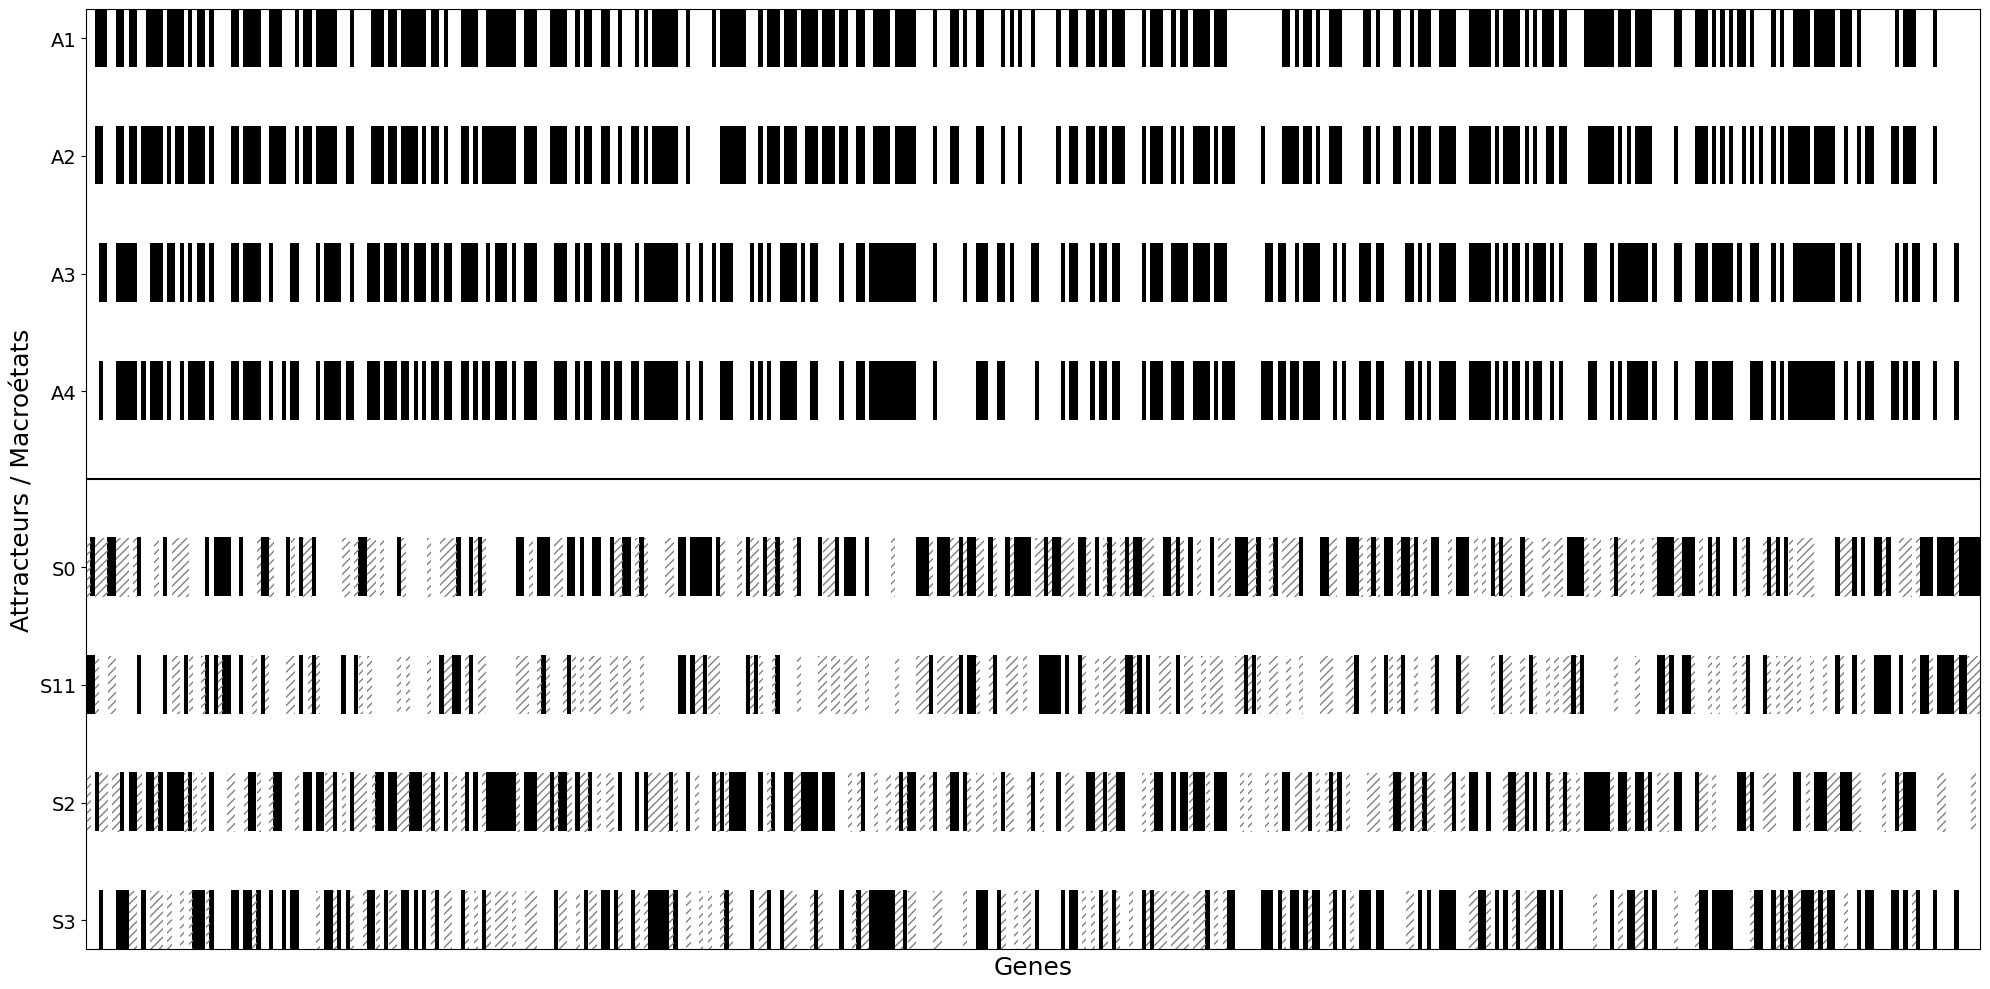

In [9]:
# Commons genes 
common_genes = [g for g in attractors.columns if g in data.columns]

df_common = attractors[common_genes]
data_common = data[common_genes]

mat1 = df_common.values
mat2 = data_common.values

n_rows1, n_cols = mat1.shape
n_rows2, _ = mat2.shape

# Space between matrix 
def space_matrix(mat):
    n_rows, n_cols = mat.shape
    spaced = np.full((n_rows * 2 - 1, n_cols), np.nan)pourcentage de gènes identiques
    spaced[::2] = mat
    return spaced

mat1_spaced = space_matrix(mat1)
mat2_spaced = space_matrix(mat2)

# Space between matrix 
gap = 2
sep = np.full((gap, n_cols), np.nan)

full_mat = np.vstack([mat1_spaced, sep, mat2_spaced])

# Mask for Nan
real_data_mask = np.zeros_like(full_mat, dtype=bool)
real_data_mask[0:mat1_spaced.shape[0]:2, :] = True
offset = mat1_spaced.shape[0] + gap
real_data_mask[offset::2, :] = True

nan_to_hatch = np.isnan(full_mat) & real_data_mask

# Colormap
cmap = plt.cm.binary.copy()
cmap.set_bad(color="white", alpha=0)

fig, ax = plt.subplots(figsize=(20, 10))

ax.imshow(
    full_mat,
    cmap=cmap,
    aspect="auto",
    interpolation="none",
    vmin=0, vmax=1)

for i in range(full_mat.shape[0]):
    for j in range(full_mat.shape[1]):
        if nan_to_hatch[i, j]:
            ax.add_patch(mpatches.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                facecolor="none",
                edgecolor="grey",
                hatch="////",
                linewidth=0
            ))

#Ticks
yticks_pos = list(range(0, mat1_spaced.shape[0], 2)) + \
             [offset + i for i in range(0, mat2_spaced.shape[0], 2)]
yticks_labels = [f"A{i+1}" for i in range(n_rows1)] + list(data_common.index)
ax.set_yticks(yticks_pos)
ax.set_yticklabels(yticks_labels, fontsize=14)
ax.axhline(mat1_spaced.shape[0] + gap / 2 - 0.5, color="black", linewidth=1.5)
ax.set_xticks([])
ax.set_xlabel("Genes", fontsize=18)
ax.set_ylabel("Attractors / Macrostates", fontsize=18)
plt.tight_layout()
plt.show()

### Similarity matrix 

With the Nan (NaN = false) 

macrostate        S0       S11        S2        S3
Attractor                                         
Attractor1  0.085333  0.146667  0.757333  0.530667
Attractor2  0.045333  0.074667  0.554667  0.738667


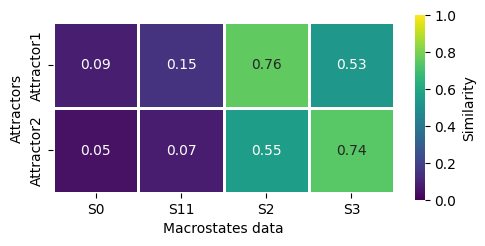

In [9]:
similarity = pd.DataFrame(
    index=attractors.index,
    columns=data.index,
    dtype=float)

for attr_name, attr_row in attractors.iterrows():
    for data_name, data_row in data.iterrows():
        similarity.loc[attr_name, data_name] = np.mean(
            attr_row.values == data_row.values)

print(similarity)
plt.figure(figsize=(5,4))
sns.heatmap(similarity,annot=True,cmap="viridis",vmin=0,vmax=1,square=True,linewidths=1,fmt=".2f",cbar_kws={"label": "Similarity","shrink": 0.5})
plt.xlabel("Macrostates data")
plt.ylabel("Attractors")
plt.tight_layout()
plt.show()

Keep only gene without Nan per macrostates 

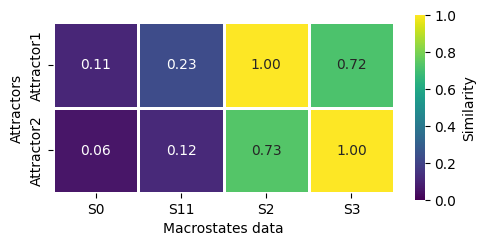

In [10]:
similarity = pd.DataFrame(
    index=attractors.index,
    columns=data.index,
    dtype=float)

for attr_name, attr_row in attractors.iterrows():
    for data_name, data_row in data.iterrows():
        mask = ~pd.isna(data_row.values)
        similarity.loc[attr_name, data_name] = np.mean(
            attr_row.values[mask] == data_row.values[mask]
        )
        
plt.figure(figsize=(5,4))
sns.heatmap(similarity,annot=True,cmap="viridis",vmin=0,vmax=1,square=True,linewidths=1,fmt=".2f",cbar_kws={"label": "Similarity","shrink": 0.5})
plt.xlabel("Macrostates data")
plt.ylabel("Attractors")
plt.tight_layout()
plt.show()

Similarity between S2 and S3

In [11]:
# Without NaN
s2 = data.loc["S2"]
s3 = data.loc["S3"]

mask = s2.notna() & s3.notna()

similarity = (s2[mask] == s3[mask]).mean()

print(similarity)

# With NaN
equal = ((s2 == s3) |(s2.isna() & s3.isna()))

similarity = equal.mean()

print(similarity)

0.5967741935483871
0.296


Dotplot (same than the similarity matrix, but with the size, number of genes) 

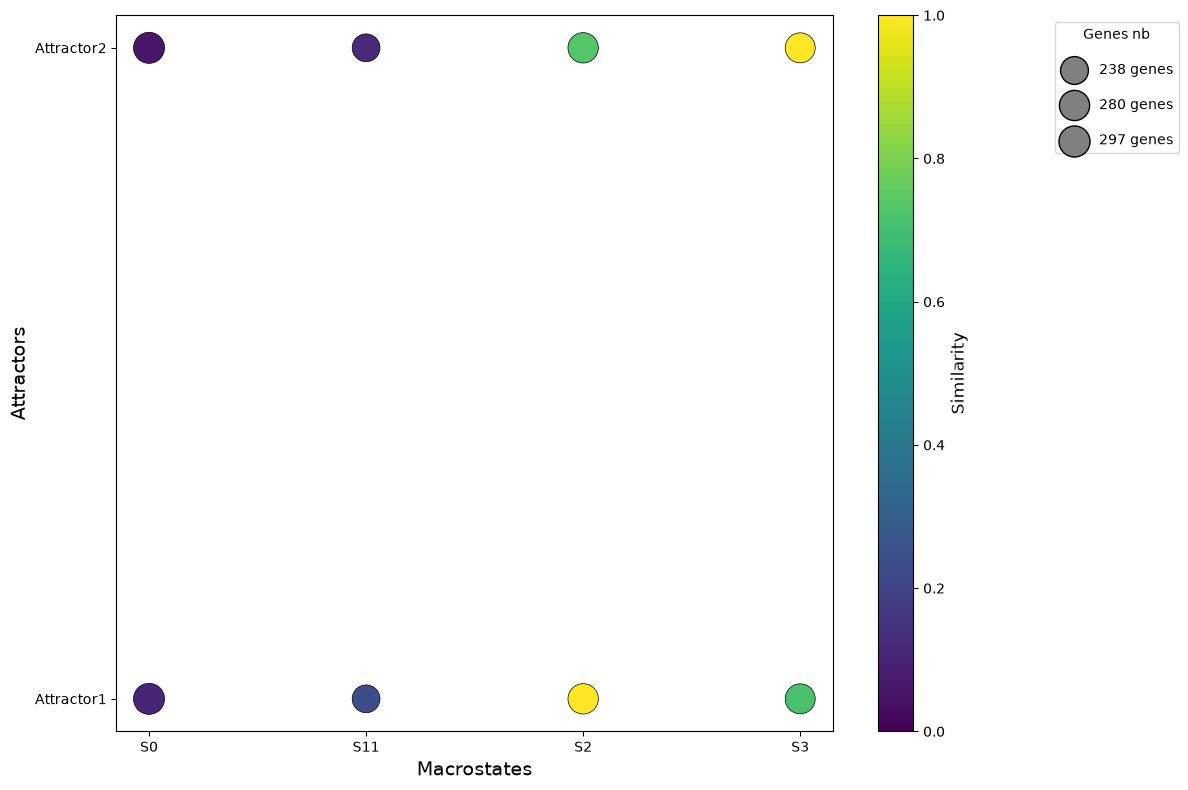

In [7]:
similarity = pd.DataFrame(
    index=attractors.index,
    columns=data.index,
    dtype=float)

n_genes_used = pd.DataFrame(index=attractors.index, columns=data.index, dtype=int)

for attr_name, attr_row in attractors.iterrows():
    for data_name, data_row in data.iterrows():
        mask = ~pd.isna(data_row.values)
        similarity.loc[attr_name, data_name] = np.mean(
            attr_row.values[mask] == data_row.values[mask])
        n_genes_used.loc[attr_name, data_name] = mask.sum()

attr_names = similarity.index
data_names = similarity.columns

xs, ys, sizes, colors = [], [], [], []

for i, attr_name in enumerate(attr_names):
    for j, data_name in enumerate(data_names):
        xs.append(j)
        ys.append(i)
        colors.append(similarity.loc[attr_name, data_name])
        sizes.append(n_genes_used.loc[attr_name, data_name])

sizes = np.array(sizes, dtype=float)
sizes_scaled = (sizes / sizes.max()) * 500

#dotplot
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    xs, ys,
    s=sizes_scaled,
    c=colors,
    cmap="viridis",
    vmin=0, vmax=1,
    edgecolors="black",
    linewidths=0.5)

# Ticks and labels
ax.set_xticks(range(len(data_names)))
ax.set_xticklabels(data_names, rotation=0, fontsize=10)
ax.set_yticks(range(len(attr_names)))
ax.set_yticklabels(attr_names, fontsize=10)

ax.set_xlabel("Macrostates", fontsize=14)
ax.set_ylabel("Attractors", fontsize=14)

#Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Similarity", fontsize=12)

# Legend
for n in [sizes.min(), np.median(sizes), sizes.max()]:
    plt.scatter([], [], s=(n / sizes.max()) * 500, c="grey", edgecolors="black", label=f"{int(n)} genes")
plt.legend(scatterpoints=1, frameon=True, labelspacing=1.5, title="Genes nb", bbox_to_anchor=(1.3, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Reachability 

In [12]:
# Network
bn = mpbn.MPBooleanNetwork(model_file)

# Macrostates
df = pd.read_csv(data_file, index_col=0)
macrostates = {}

for name, row in df.iterrows():
    state = {}
    for gene, value in row.items():
        if pd.isna(value):
            continue
        if value == "*":
            continue
        state[gene] = int(value)
    macrostates[name] = state

# Matrix calcul
reach = pd.DataFrame(
    0,
    index=macrostates.keys(),
    columns=macrostates.keys())

for source_name, source in macrostates.items():
    for target_name, target in macrostates.items():

        if bn.reachability(source, target):
            reach.loc[source_name, target_name] = 1

print(reach)

     S0  S11  S2  S3
S0    1    0   0   0
S11   0    1   0   0
S2    0    0   1   0
S3    0    0   0   1


In [13]:
#! pip install scanpy
#! pip install --upgrade typing_extensions --break-system-packages
import scanpy as sc

adata = sc.read("cll_macro_stream_13.h5ad") # read data 
# Delete cells with macrostates == "None"
adata = adata[adata.obs["macrostates"] != "None"].copy()
sc.pp.normalize_total(adata) 
sc.pp.log1p(adata)

# TFs expected (DEG TF activity between B cells and bridge) from SCENIC
TF=["CEBPD","CEBPA","ZNF333","ELF4","NFATC2","RFXAP","NANOG","LHX4","PAX7","ZNF250","IKZF2","HOXA5","ZFP92","SPI1",
 "FOSL2","OVOL3","ELF3","NFIX","FOS","TGIF1","IRF4","IRF1"]

# Genes expected by DEG between the macrostates 
sc.tl.rank_genes_groups(adata,groupby="macrostates",method="wilcoxon",use_raw=False)
groups = adata.obs["macrostates"].unique()
all_sig_genes = set()
for g in groups:
    df = sc.get.rank_genes_groups_df(adata, group=g)
    df_sig = df[
        (df["pvals_adj"] < 0.01) &
        (df["logfoldchanges"] > 4)
    ]
    all_sig_genes.update(df_sig["names"].tolist())

genes = sorted(all_sig_genes)
print(f"{len(genes)} significatif genes")


# Genes list total
gene_list = list(set(genes + TF))

print(f"{len(gene_list)} genes+TF present")

33 significatif genes
55 genes+TF present


In [15]:
core_genes = ["CEBPA", "SPI1", "CEBPB", "IRF4", "NFKB1", "CEBPE","MYC","NANOG","FOS","BACH2","SP1","CEBPD","PAX7","PAX5"] 
macrostates_core = {
    name: {g: v for g, v in state.items() if g in core_genes}
    for name, state in macrostates.items()
}

for name, state in macrostates_core.items():
    print(name, state)

reach = pd.DataFrame(0, index=macrostates_core.keys(), columns=macrostates_core.keys())
for s_name, s in macrostates_core.items():
    for t_name, t in macrostates_core.items():
        reach.loc[s_name, t_name] = int(bn.reachability(s, t))
print(reach)

S0 {'CEBPA': 0, 'CEBPB': 0, 'CEBPD': 0, 'IRF4': 0, 'MYC': 0}
S11 {'BACH2': 1, 'CEBPA': 0, 'CEBPB': 0, 'CEBPD': 0, 'IRF4': 0, 'MYC': 0, 'NFKB1': 0}
S2 {'BACH2': 0, 'CEBPA': 1, 'CEBPB': 1, 'CEBPD': 1, 'FOS': 1, 'IRF4': 0, 'MYC': 0, 'NFKB1': 0, 'PAX5': 0, 'SPI1': 1}
S3 {'BACH2': 0, 'CEBPA': 0, 'CEBPB': 1, 'CEBPD': 0, 'FOS': 0, 'IRF4': 1, 'MYC': 1, 'NFKB1': 1, 'SPI1': 0}
     S0  S11  S2  S3
S0    1    1   0   1
S11   1    1   0   1
S2    0    0   1   0
S3    0    0   0   1


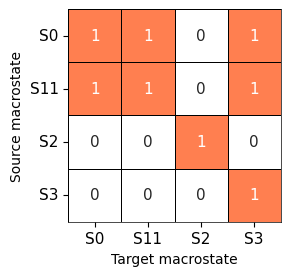

In [16]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "coral"])
fig, ax = plt.subplots(figsize=(3, 3))
sns.heatmap(reach,annot=True,fmt="d",cmap=cmap,cbar=False,linewidths=0.5,linecolor="black",square=True,vmin=0,vmax=1,annot_kws={"fontsize": 11},ax=ax)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_edgecolor("black")

# Labels
ax.set_xlabel("Target macrostate", fontsize=10)
ax.set_ylabel("Source macrostate", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
# Save
# plt.savefig(f"{output_directory}/reachability_matrix.png", dpi=300,bbox_inches="tight")
plt.show()

Transition probability matrix 

Executed on the Docker image Colomoto colomoto/colomoto-docker

In [17]:
# Conversion bnet into bnd
import biolqm
lqm = biolqm.load(model_file)
biolqm.save(lqm, "model.bnd")

'model.bnd'

In [18]:
import math
import maboss
from collections import defaultdict

BND_FILE = "model.bnd"
CFG_FILE = "model.bnd.cfg"

NODE_ORDER = data.columns.tolist()

# Group all vectors by macro-state (list, not just one)
MACRO_STATE_VECTORS = defaultdict(list)
for macro, row in data.iterrows():
    MACRO_STATE_VECTORS[macro].append(row.tolist())

def vector_to_pattern(vector, node_order):
    return {
        node: int(val)
        for node, val in zip(node_order, vector)
        if not (isinstance(val, float) and math.isnan(val))
    }

# Now each macrostate has a list of possible patterns
MACRO_STATES = {
    name: [vector_to_pattern(vec, NODE_ORDER) for vec in vecs]
    for name, vecs in MACRO_STATE_VECTORS.items()
}

# Union of all constrained nodes, across all vectors
MARKER_NODES = sorted({
    n for patterns in MACRO_STATES.values()
    for pattern in patterns
    for n in pattern
})

MAX_TIME = 50
TIME_TICK = 1
SAMPLE_COUNT = 5000

def label_from_state_name(state_name, marker_nodes):
    active = set(state_name.replace("(", "").replace(")", "").split(" -- ")) if state_name != "<nil>" else set()
    return tuple(1 if n in active else 0 for n in marker_nodes)

def match_label_to_macro(label, marker_nodes):
    """Check whether the label matches at least one of the patterns for a macrostate."""
    for name, patterns in MACRO_STATES.items():
        for pat in patterns:
            expected = tuple(pat.get(n, None) for n in marker_nodes)
            if all(e is None or e == l for e, l in zip(expected, label)):
                return name
    return str(label)

def run_from_pattern(pattern):
    sim = maboss.load(BND_FILE, CFG_FILE)
    for node, val in pattern.items():
        sim.network.set_istate(node, [1 - val, val])
    for node in sim.network.names:
        if node not in pattern:
            sim.network.set_istate(node, [0.5, 0.5])
    sim.update_parameters(max_time=MAX_TIME, time_tick=TIME_TICK, sample_count=SAMPLE_COUNT)
    result = sim.run()
    probtraj = result.get_last_states_probtraj()
    return probtraj.iloc[0].to_dict()

def run_from_macro(patterns):
    """If a macrostate has several representative vectors, we simulate from each one and average the final distributions (equal weights)."""
    combined = defaultdict(float)
    for pattern in patterns:
        probs = run_from_pattern(pattern)
        for state_name, p in probs.items():
            combined[state_name] += p / len(patterns)
    return combined

def build_transition_matrix():
    matrix = {}
    for macro_i, patterns in MACRO_STATES.items():
        final_probs = run_from_macro(patterns)
        row = {}
        for state_name, p in final_probs.items():
            label = label_from_state_name(state_name, MARKER_NODES)
            matched = match_label_to_macro(label, MARKER_NODES)
            row[matched] = row.get(matched, 0) + p
        matrix[macro_i] = row
    return matrix

def print_matrix(matrix):
    labels = sorted({k for row in matrix.values() for k in row})
    print("\t" + "\t".join(labels))
    for i, row in matrix.items():
        print(i + "\t" + "\t".join(f"{row.get(j, 0):.2f}" for j in labels))

matrix = build_transition_matrix()
print_matrix(matrix)

Menu MaBoSS is already registered
	S2	S3
S0	0.37	0.63
S11	0.50	0.50
S2	0.63	0.37
S3	0.50	0.50


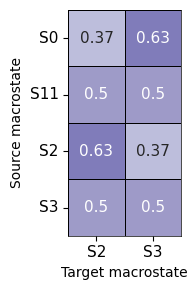

In [19]:
from matplotlib.colors import ListedColormap
matrix_df = pd.DataFrame(matrix).T
matrix_df = matrix_df.fillna(0)

fig, ax = plt.subplots(figsize=(3, 3))
sns.heatmap(matrix_df,annot=True,cmap="Purples",cbar=False,linewidths=0.5,linecolor="black",square=True,vmin=0,vmax=1,annot_kws={"fontsize": 11},ax=ax)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_edgecolor("black")

# Labels
ax.set_xlabel("Target macrostate", fontsize=10)
ax.set_ylabel("Source macrostate", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
# Save
# plt.savefig(f"{output_directory}/reachability_matrix.png", dpi=300,bbox_inches="tight")
plt.show()

### UMAP